<IPython.core.display.Math object>

<IPython.core.display.Math object>

n,fn,g(fn),g '(fn),Error (En)
0,0.020000,-2.345373e-01,-1.954354e+02,nan
1,0.018800,1.079783e-02,-2.139006e+02,0.001200
2,0.018850,2.111020e-05,-2.130651e+02,0.000050
3,0.018851,8.096279e-11,-2.130635e+02,0.000000


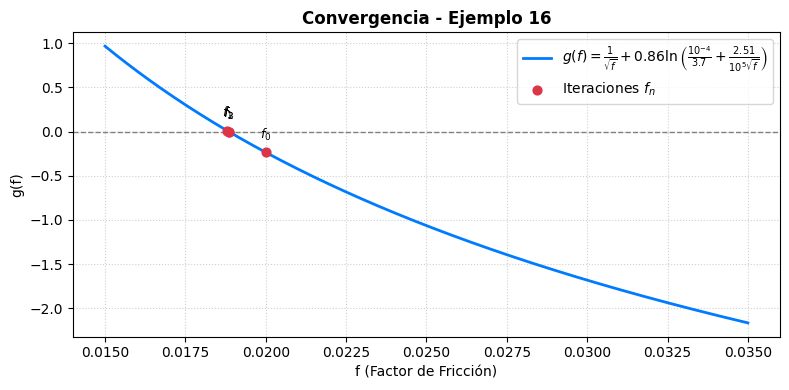

In [13]:
import sympy as sp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Math

def newton_raphson_ejemplo16(f0_val=0.02, tol=1e-6, max_iter=100):
    # 1. Definir la variable simbólica
    f = sp.Symbol('f', positive=True)

    # 2. Función exacta con los valores dados en el LaTeX:
    # g(f) = 1/sqrt(f) + 0.86 * ln(10^-4 / 3.7 + 2.51 / (10^5 * sqrt(f)))
    ed = 1e-4
    Re = 1e5
    coef = 0.86

    g_expr = 1/sp.sqrt(f) + coef * sp.log((ed / 3.7) + (2.51 / (Re * sp.sqrt(f))))
    dg_expr = sp.diff(g_expr, f)

    # Encabezado HTML
    html_header = """
    <div style="background-color: #f8f9fa; border-left: 5px solid #007bff; padding: 15px; margin-bottom: 15px; border-radius: 4px;">
        <h2 style="color: #007bff; margin-top: 0; font-family: sans-serif;">Método de Newton-Raphson</h2>
        <p style="font-size: 15px; font-family: sans-serif; color: #333;">
            Ejemplo 16: Factor de Fricción (Colebrook-White con coeficiente 0.86)
        </p>
    </div>
    """
    display(HTML(html_header))

    display(Math(rf"\mathbf{{Función\ evaluada:}}\quad g(f) = \frac{{1}}{{\sqrt{{f}}}} + 0.86 \ln\left(\frac{{10^{{-4}}}}{{3.7}} + \frac{{2.51}}{{10^5 \sqrt{{f}}}}\right) = 0"))
    display(Math(rf"\mathbf{{Derivada\ analítica:}}\quad g'(f) = {sp.latex(dg_expr)}"))

    # 3. Conversión a funciones numéricas ejecutables
    g_num = sp.lambdify(f, g_expr, modules=['numpy'])
    dg_num = sp.lambdify(f, dg_expr, modules=['numpy'])

    # 4. Algoritmo de Newton-Raphson
    iteraciones = []
    f_n = float(f0_val)

    for n in range(max_iter):
        gfx = float(g_num(f_n))
        dgfx = float(dg_num(f_n))

        error = np.nan if n == 0 else abs(f_n - f_prev)

        iteraciones.append({
            'n': n,
            'f_n': f_n,
            'g(f_n)': gfx,
            'g\'(f_n)': dgfx,
            'Error': error
        })

        if n > 0 and error < tol:
            break

        f_prev = f_n
        f_n = f_n - (gfx / dgfx)

    df_res = pd.DataFrame(iteraciones)

    # Formato visual de la tabla coincidente con LaTeX
    df_res_styled = df_res.copy()
    df_res_styled.columns = [
        '<i>n</i>',
        '<i>f<sub>n</sub></i>',
        '<i>g(f<sub>n</sub>)</i>',
        '<i>g \'(f<sub>n</sub>)</i>',
        '<i>Error (E<sub>n</sub>)</i>'
    ]

    tabla_styled = df_res_styled.style.format({
        '<i>f<sub>n</sub></i>': '{:.6f}',
        '<i>g(f<sub>n</sub>)</i>': '{:.6e}',
        '<i>g \'(f<sub>n</sub>)</i>': '{:.6e}',
        '<i>Error (E<sub>n</sub>)</i>': '{:.6f}'
    }).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#007bff'),
            ('color', '#ffffff'),
            ('font-family', 'sans-serif'),
            ('font-size', '14px'),
            ('text-align', 'center'),
            ('padding', '10px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('font-family', 'monospace'),
            ('font-size', '13px'),
            ('padding', '8px')
        ]}
    ]).hide(axis='index')

    display(HTML("<h3 style='font-family: sans-serif; color: #333;'>Tabla de Iteraciones</h3>"))
    display(tabla_styled)

    # Solución corregida usando formato HTML nativo para f ≈
    raiz_final = df_res.iloc[-1]['f_n']
    num_iter = int(df_res.iloc[-1]['n'])

    display(HTML(f"""
    <div style="background-color: #d4edda; color: #155724; padding: 12px; border-radius: 5px; margin-top: 15px; border: 1px solid #c3e6cb; font-family: sans-serif;">
        <strong>Convergencia alcanzada:</strong> Solución <i>f</i> &approx; <code>{raiz_final:.5f}</code> en <strong>{num_iter}</strong> iteraciones.
    </div>
    """))

    return df_res, g_num

# ==================== EJECUCIÓN Y GRÁFICA ====================
df_resultados, g_func = newton_raphson_ejemplo16(f0_val=0.02, tol=1e-6)

# Gráfica de convergencia
f_vals = np.linspace(0.015, 0.035, 400)
plt.figure(figsize=(8, 4), facecolor='#ffffff')
plt.plot(f_vals, g_func(f_vals), label=r"$g(f) = \frac{1}{\sqrt{f}} + 0.86 \ln\left(\frac{10^{-4}}{3.7} + \frac{2.51}{10^5 \sqrt{f}}\right)$", color='#007bff', linewidth=2)
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.scatter(df_resultados['f_n'], df_resultados['g(f_n)'], color='#dc3545', zorder=5, s=40, label='Iteraciones $f_n$')

for i, row in df_resultados.iterrows():
    n_val = int(row['n'])
    plt.annotate(f"$f_{{{n_val}}}$",
                 (row['f_n'], row['g(f_n)']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.title('Convergencia - Ejemplo 16', fontsize=12, fontweight='bold')
plt.xlabel('f (Factor de Fricción)', fontsize=10)
plt.ylabel('g(f)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()